<a href="https://colab.research.google.com/github/annkupina/ml_course_hw/blob/main/Anna_Kupina_HW_2_2_%D0%9F%D0%BE%D0%BB%D1%96%D0%BD%D0%BE%D0%BC%D1%96%D0%B0%D0%BB%D1%8C%D0%BD%D1%96_%D0%BE%D0%B7%D0%BD%D0%B0%D0%BA%D0%B8_Pipelines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import f1_score, confusion_matrix, roc_curve, auc, root_mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import joblib


Area under ROC score on Train dataset: 0.88


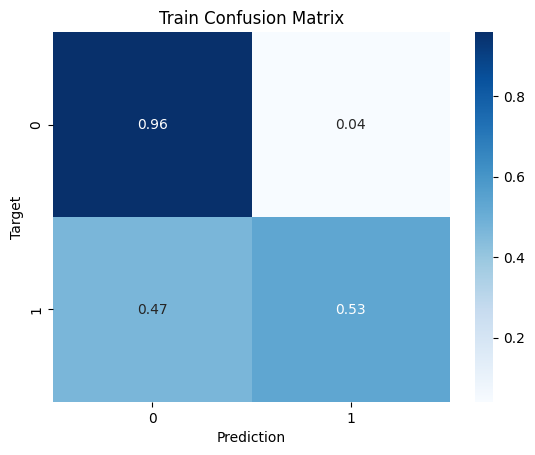

Area under ROC score on Validation dataset: 0.88


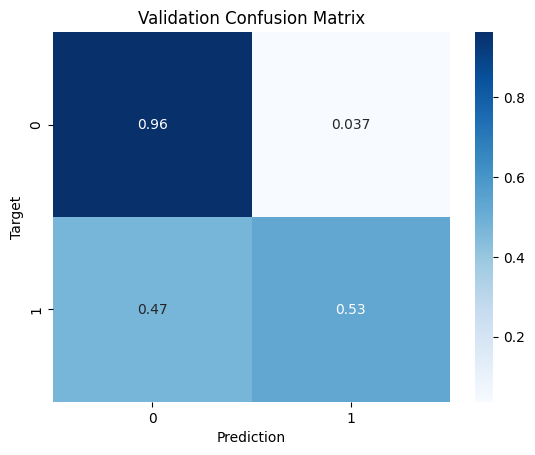

['log_reg.joblib']

In [4]:
raw_df = pd.read_csv('train.csv', index_col=0)

train_df, val_df = train_test_split(raw_df, test_size=0.25, random_state=35, stratify= raw_df['Exited'])

# Створюємо трен. і вал. набори
input_cols = list(train_df.columns)[2:-1]
target_col = 'Exited'
train_inputs, train_targets = train_df[input_cols].copy(), train_df[target_col].copy()
val_inputs, val_targets = val_df[input_cols].copy(), val_df[target_col].copy()

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    probs = model_pipeline.predict_proba(inputs)[:, 1]
    fpr, tpr, thresholds = roc_curve(targets, probs, pos_label=1)
    roc_auc = auc(fpr, tpr)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}")
    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline, 'log_reg.joblib')


**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

Area under ROC score on Train (Poly 2) dataset: 0.92


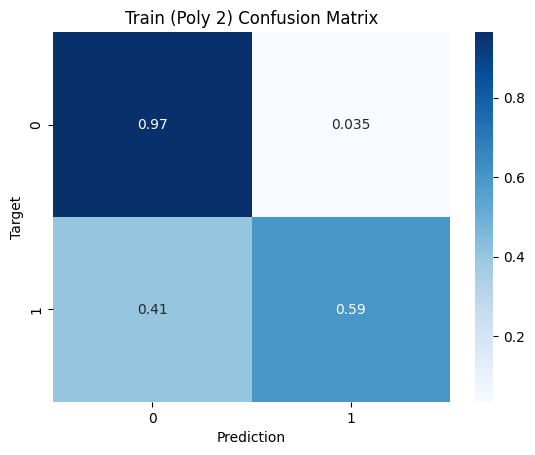

Area under ROC score on Validation (Poly 2) dataset: 0.92


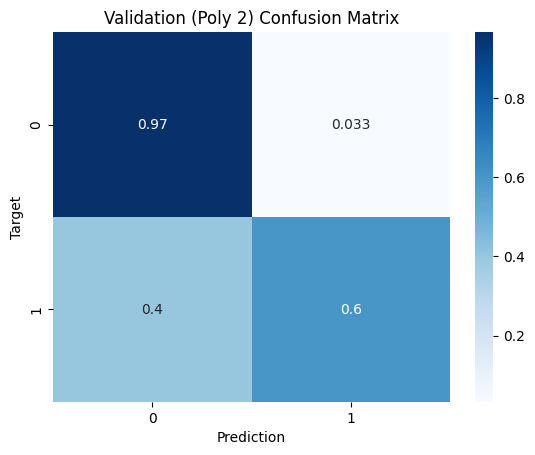

In [5]:
import operator
from sklearn.preprocessing import PolynomialFeatures

numeric_transformer_poly_2 = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('polynomial_features ', PolynomialFeatures(degree=2))
])

preprocessor_poly_2 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly_2, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

model_pipeline_poly_2 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly_2),
    ('classifier', LogisticRegression(solver='liblinear'))
])

model_pipeline_poly_2.fit(train_inputs, train_targets)

train_preds_poly = predict_and_plot(model_pipeline_poly_2, train_inputs, train_targets, 'Train (Poly 2)')
val_preds_poly = predict_and_plot(model_pipeline_poly_2, val_inputs, val_targets, 'Validation (Poly 2)')

Ця модель вже краще попередньої, ознак overfit або underfit немає. Модель добре генералізує дані.

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

Area under ROC score on Train (Poly 4) dataset: 0.93


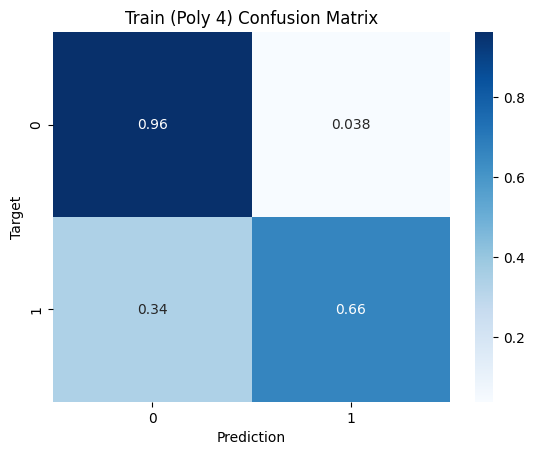

Area under ROC score on Validation (Poly 4) dataset: 0.93


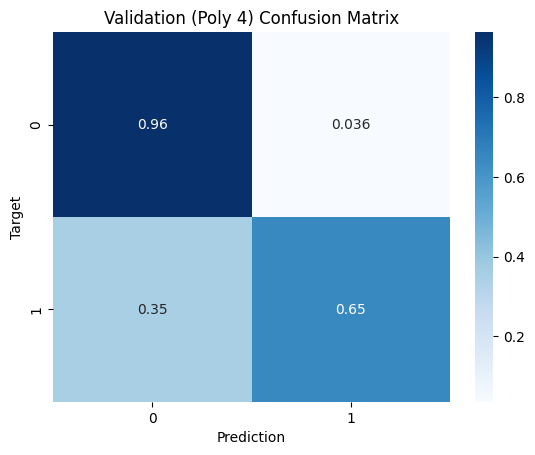

In [6]:
numeric_transformer_poly_4 = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('polynomial_features ', PolynomialFeatures(degree=4))
])

preprocessor_poly_4 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly_4, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

model_pipeline_poly_4 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly_4),
    ('classifier', LogisticRegression(solver='liblinear'))
])

model_pipeline_poly_4.fit(train_inputs, train_targets)

train_preds_poly = predict_and_plot(model_pipeline_poly_4, train_inputs, train_targets, 'Train (Poly 4)')
val_preds_poly = predict_and_plot(model_pipeline_poly_4, val_inputs, val_targets, 'Validation (Poly 4)')

Ця модель виглядає ще краще ніж попередня і не перенавчена.

**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [7]:
raw_regression_df = pd.read_csv('regression_data.csv')

X = raw_regression_df.drop(columns=['target'])
y = raw_regression_df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
poly_features = PolynomialFeatures(degree=5)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

scaler = MinMaxScaler()
X_train_poly_scaled = scaler.fit_transform(X_train_poly)
X_test_poly_scaled = scaler.transform(X_test_poly)

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)
y_pred_train_poly = poly_reg.predict(X_train_poly)
y_pred_test_poly = poly_reg.predict(X_test_poly)

rmse_poly_train = root_mean_squared_error(y_train, y_pred_train_poly)
rmse_poly_test = root_mean_squared_error(y_test, y_pred_test_poly)

print(f"Train RMSE for Polynomial Regression (degree 5): {np.sqrt(rmse_poly_train):.8f}")
print(f"Test RMSE for Polynomial Regression (degree 5): {np.sqrt(rmse_poly_test):.3f}")

Train RMSE for Polynomial Regression (degree 5): 0.00000048
Test RMSE for Polynomial Regression (degree 5): 5.425


Ця модель перенавчена, на тренувальних даних дуже мала помилка, а на тестувальних в рази більша. Модель погано генералізує дані.

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [9]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
models = [
    Ridge(),
    Lasso(),
    ElasticNet()
]

In [10]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_metrics = root_mean_squared_error(y_train, y_train_pred)
    test_metrics = root_mean_squared_error(y_test, y_test_pred)

    return dict(train=train_metrics, test=test_metrics)

In [11]:
poly_features = PolynomialFeatures(degree=20)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

In [12]:
import warnings

warnings.filterwarnings("ignore")

for model in models:
    model.fit(X_train_poly, y_train)
    eval_results  = evaluate_model(model, X_train_poly, y_train, X_test_poly, y_test)
    print(f'{str(model)}: {eval_results}\n')

Ridge(): {'train': 32.58206767922066, 'test': 9034.945944005218}

Lasso(): {'train': 2.313505449570354, 'test': 68.31879121877043}

ElasticNet(): {'train': 10.159852342199374, 'test': 1526.8209205681153}



Всі ці моделі мають сильний overfit. Найкраща з чотирьох є Lasso, бо в неї найменша різниця в помилках для тренувальних і тестувальних даних.
Якщо всі ці моделі мають оверфіт, то можливо потрібно спробувати більш просту модель, може поліноміальну з меньшим ступенем ніж 5, або просту лінійну регресію.